In [4]:
import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [5]:
print("Missing values before further cleaning:\n", df.isnull().sum())

Missing values before further cleaning:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


It looks like there are no missing values in the dataset, which suggests previous cleaning steps were effective. Now, I will convert the `Churn` column to a numerical format (0 for 'No', 1 for 'Yes') and drop the `customerID` column, as it's not useful for modeling.

In [6]:
# Convert 'Churn' column to numerical (0 for No, 1 for Yes)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop 'customerID' column as it is an identifier and not useful for prediction
# Add a check to see if the column exists before dropping it
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("customerID column dropped.")
else:
    print("customerID column not found, it might have been dropped already.")

print("DataFrame after converting 'Churn' and potentially dropping 'customerID':")
display(df.head())

customerID column dropped.
DataFrame after converting 'Churn' and potentially dropping 'customerID':


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
import zipfile
import os

# Unzip the archive
zip_file_path = '/content/archive.zip'
extraction_path = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Assuming the CSV file name after extraction
extracted_csv_path = os.path.join(extraction_path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"CSV file extracted to: {extracted_csv_path}")

CSV file extracted to: /content/WA_Fn-UseC_-Telco-Customer-Churn.csv


### Fixing the 'Churn' Column and Feature Engineering

It appears that after mapping, the `Churn` column contains `NaN` values. This usually happens when there are values other than 'Yes' or 'No' in the original column that the `.map()` function cannot convert. We will reload the dataset to ensure data integrity, correctly handle the `TotalCharges` column, and then re-process the `Churn` column. Afterward, we'll proceed with feature engineering.

In [8]:
import pandas as pd
import numpy as np

# Reload the dataset to get the original 'Churn' values
df_original = pd.read_csv(extracted_csv_path)

# Re-process 'TotalCharges' column and handle missing values
df_original['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'], errors='coerce')
df_original.dropna(inplace=True)

# Display unique values of the 'Churn' column before mapping
print("Unique values in 'Churn' before mapping:", df_original['Churn'].unique())

# Map 'Churn' to numerical (0 for No, 1 for Yes)
df_original['Churn'] = df_original['Churn'].map({'Yes': 1, 'No': 0})

# Drop 'customerID' column
if 'customerID' in df_original.columns:
    df_original = df_original.drop('customerID', axis=1)

df = df_original.copy() # Update the working DataFrame

print("DataFrame after re-processing 'Churn' and dropping 'customerID':")
display(df.head())

Unique values in 'Churn' before mapping: ['No' 'Yes']
DataFrame after re-processing 'Churn' and dropping 'customerID':


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Now that our `Churn` column is correctly formatted, let's prepare the data for modeling using feature engineering techniques like one-hot encoding for categorical features and standardization for numerical features.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify categorical and numerical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape of processed training data:", X_train_processed.shape)
print("Shape of processed testing data:", X_test_processed.shape)

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()
print("Number of features after preprocessing:", len(feature_names))

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape of processed training data: (5625, 45)
Shape of processed testing data: (1407, 45)
Number of features after preprocessing: 45


### Data Visualization and Exploration

Let's create some graphs to better understand the data distribution and relationships between features, especially concerning churn.

Churn Rate: 26.58%
No Churn Rate: 73.42%


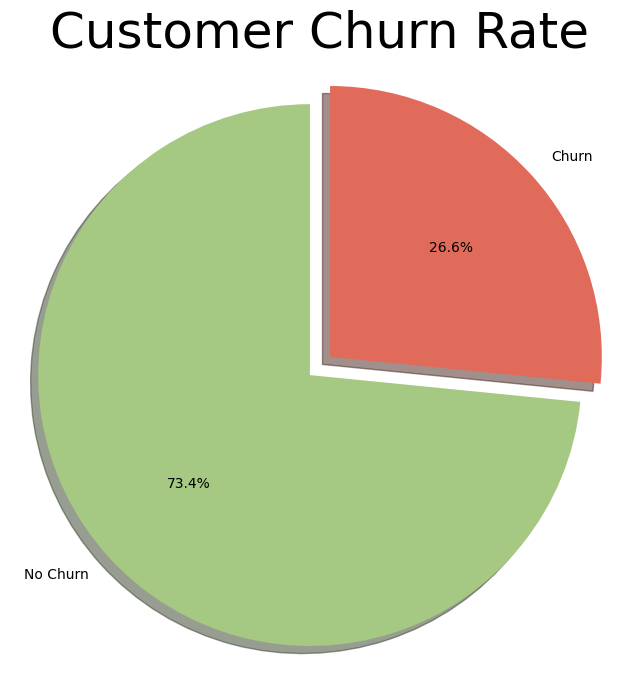

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn count
churn_counts = df['Churn'].value_counts()

# Calculate churn rate (percentage)
total_customers = churn_counts.sum()
churn_rate = churn_counts[1] / total_customers * 100
no_churn_rate = churn_counts[0] / total_customers * 100

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"No Churn Rate: {no_churn_rate:.2f}%")

# Create a pie chart
labels = ['No Churn', 'Churn']
sizes = [no_churn_rate, churn_rate]
colors = ['#a5c882','#e16b5a'] # Updated colors for better contrast
explode = (0, 0.1)  # Emphasize the churn slice

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Customer Churn Rate', fontsize=36)
plt.show()

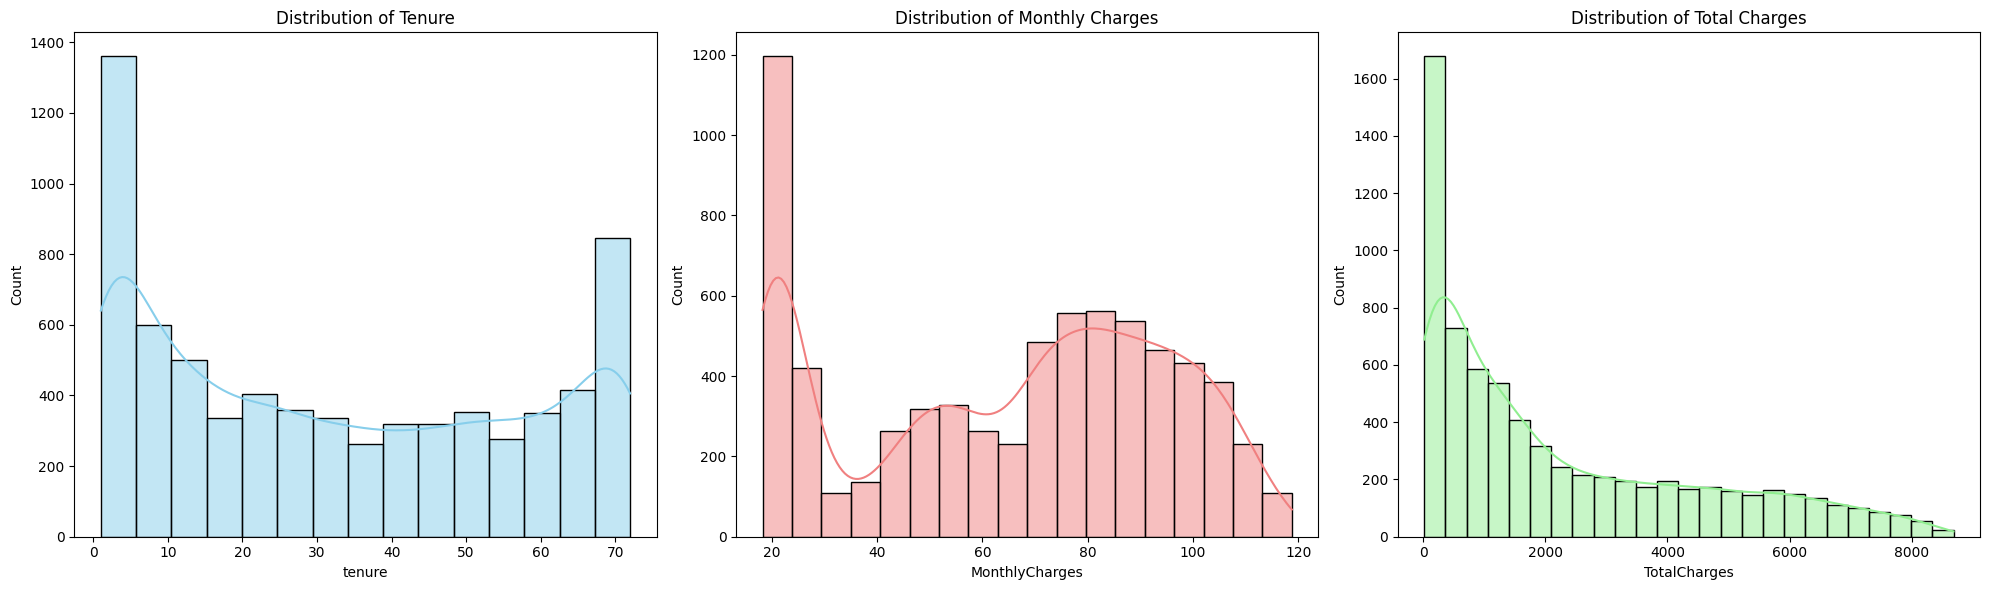

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.histplot(df['tenure'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Tenure')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Monthly Charges')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Total Charges')
plt.tight_layout()
plt.show()

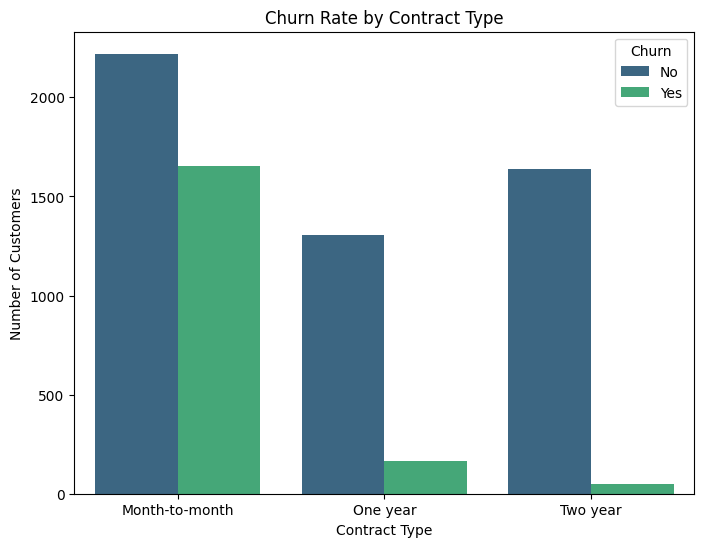

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Churn by Contract Type
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

In [13]:
pip install scikit-learn==1.5.2

In [14]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# 'preprocessor' was defined in cell 'b7f628de'
# 'X_train' and 'y_train' were also defined in cell 'b7f628de'

# Define a classifier
classifier = RandomForestClassifier(random_state=42)

# Create the full pipeline
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', classifier)])

# Train the model pipeline
model_pipeline.fit(X_train, y_train)

# Now, save the trained model pipeline
joblib.dump(model_pipeline, "model.pkl")

['model.pkl']

In [15]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy on the test set: {accuracy:.4f}")

Model Accuracy on the test set: 0.7875


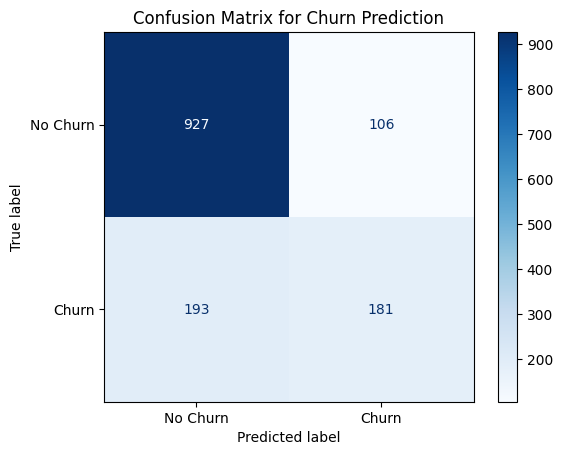

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1]) # 0 for 'No Churn', 1 for 'Churn'

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Churn Prediction')
plt.show()

In [17]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])

print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



### Feature Importance Analysis

Modelin performansını artırmak için ilk ve en önemli adımlardan biri, hangi özelliklerin tahminlerde en etkili olduğunu anlamaktır. Karar ağacı tabanlı modeller (Random Forest gibi) her özelliğe bir 'önem' skoru atayabilir. Bu skorlar, bir özelliğin modelin genel performansına ne kadar katkıda bulunduğunu gösterir.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Access the trained classifier from the pipeline
trained_classifier = model_pipeline.named_steps['classifier']

# Get feature importances
importances = trained_classifier.feature_importances_

# Get feature names after preprocessing
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 15 Feature Importances:")
display(feature_importance_df.head(15))

Top 15 Feature Importances:


,feature,importance
3,num__TotalCharges,0.163614
1,num__tenure,0.141102
2,num__MonthlyCharges,0.134536
36,cat__Contract_Month-to-month,0.051046
43,cat__PaymentMethod_Electronic check,0.031814
18,cat__OnlineSecurity_No,0.031001
16,cat__InternetService_Fiber optic,0.030541
27,cat__TechSupport_No,0.022714
0,num__SeniorCitizen,0.019752
4,cat__gender_Female,0.018498


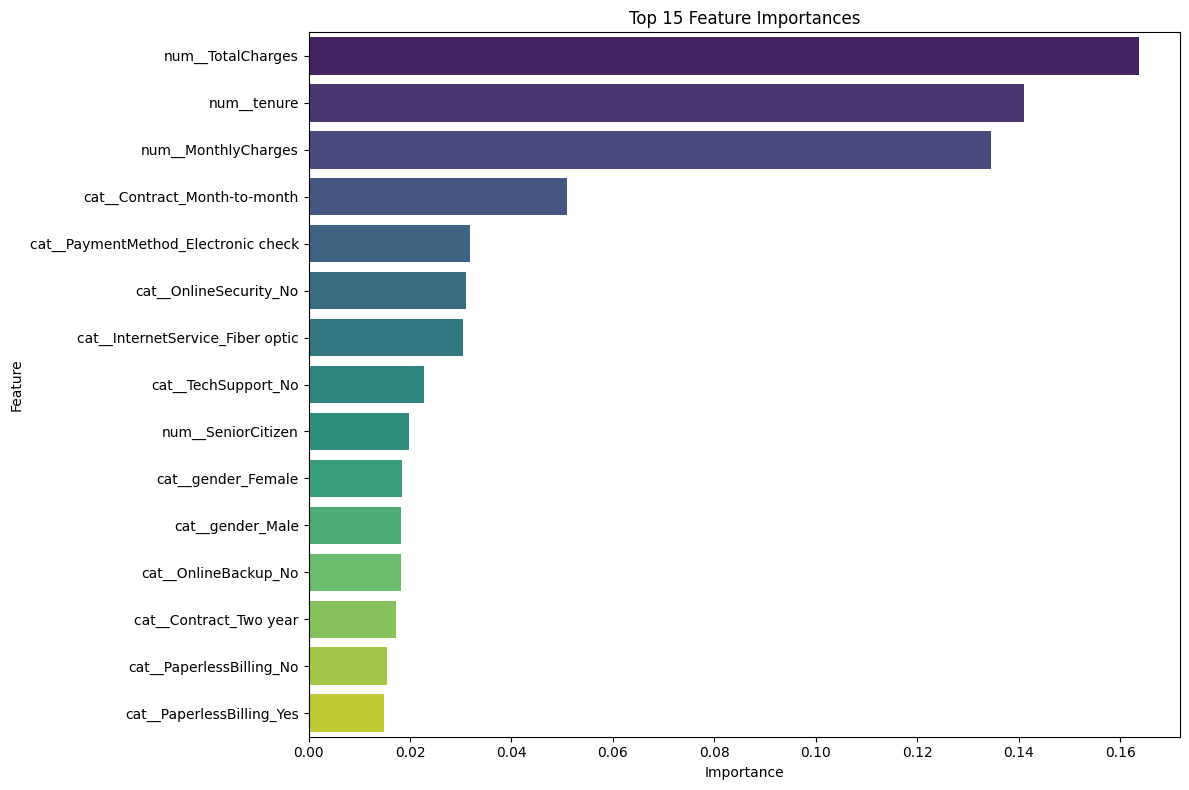

In [19]:
# Plotting the top 15 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', hue='feature', data=feature_importance_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### En Önemli Özelliklerin Churn ile İlişkisi

Modelin en önemli olarak belirlediği `TotalCharges`, `tenure` ve `MonthlyCharges` özelliklerinin churn ile nasıl bir ilişki içinde olduğunu daha iyi anlamak için bu özelliklerin churn eden ve etmeyen gruplar arasındaki dağılımlarını inceleyelim.

/tmp/ipykernel_12986/4110452385.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_12986/4110452385.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='pastel')
/tmp/ipykernel_12986/4110452385.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='pastel')


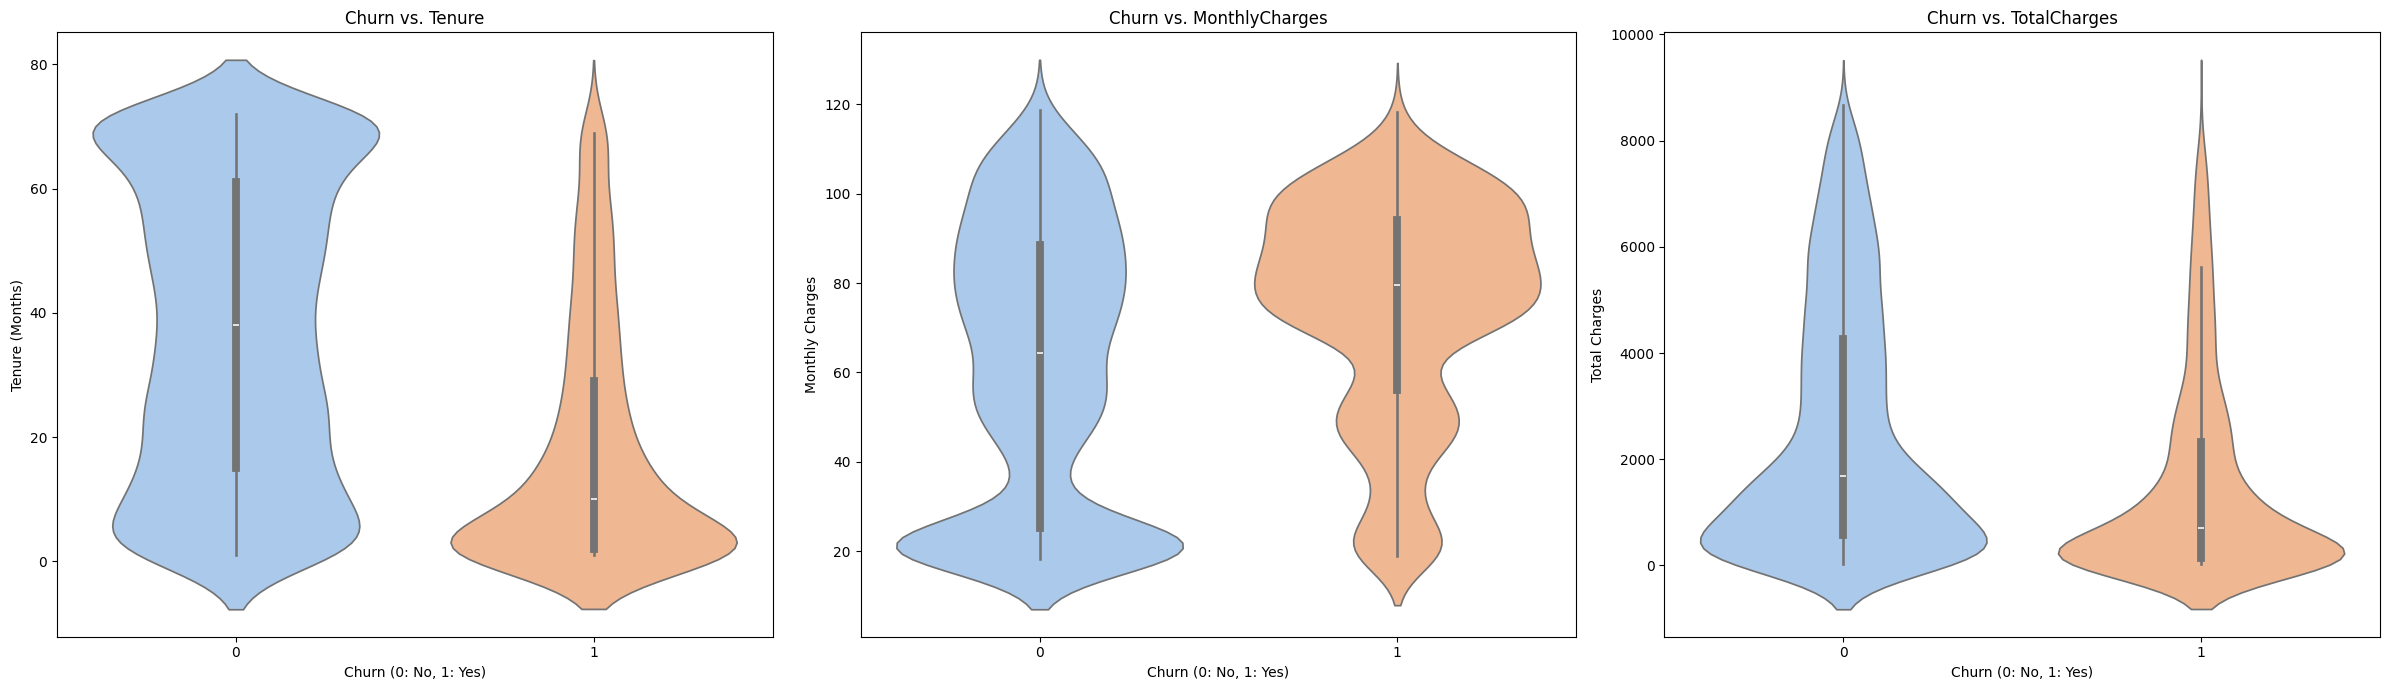

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Violin Plot for 'tenure' vs 'Churn'
sns.violinplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Churn vs. Tenure')
axes[0].set_xlabel('Churn (0: No, 1: Yes)')
axes[0].set_ylabel('Tenure (Months)')

# Violin Plot for 'MonthlyCharges' vs 'Churn'
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Churn vs. MonthlyCharges')
axes[1].set_xlabel('Churn (0: No, 1: Yes)')
axes[1].set_ylabel('Monthly Charges')

# Violin Plot for 'TotalCharges' vs 'Churn'
sns.violinplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='pastel')
axes[2].set_title('Churn vs. TotalCharges')
axes[2].set_xlabel('Churn (0: No, 1: Yes)')
axes[2].set_ylabel('Total Charges')

plt.tight_layout()
plt.show()

Bu grafiklerden şu çıkarımları yapabiliriz:

*   **Tenure (Müşteri Olma Süresi)**: Churn eden müşterilerin `tenure` dağılımının, churn etmeyenlere göre daha düşük olduğu görülüyor. Yani, yeni müşterilerin churn etme olasılığı daha yüksek. Model bu bilgiyi churn tahmininde güçlü bir şekilde kullanıyor.
*   **MonthlyCharges (Aylık Harcama)**: Churn eden müşterilerin `MonthlyCharges` dağılımı, churn etmeyenlere göre daha yüksek ortalamalara sahip gibi görünüyor. Bu, yüksek aylık ücret ödeyen müşterilerin churn etme eğiliminde olabileceğini gösterir.
*   **TotalCharges (Toplam Harcama)**: `TotalCharges` dağılımında, churn eden müşterilerde daha düşük bir yığılma gözlemlenebilirken, churn etmeyen müşterilerde daha geniş bir dağılım ve daha yüksek değerlere doğru bir eğilim vardır. Bu da `tenure` ile uyumlu bir şekilde, kısa süreli ve dolayısıyla toplamda daha az harcama yapan müşterilerin churn etme olasılığının daha yüksek olduğunu destekler.

### Streamlit Uygulaması için `app.py` Dosyası

Aşağıdaki kod, eğitilmiş modelinizi (`model.pkl`) yükleyen ve Streamlit kullanarak basit bir web uygulaması aracılığıyla yeni müşteri verileri üzerinde churn tahmini yapmanızı sağlayan `app.py` dosyasını oluşturacaktır. Bu dosyayı `/content/app.py` konumuna yazacağız.

In [21]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Model pipeline'ı yükle
# try-except bloğu, dosya bulunamazsa veya yüklenemezse hata yakalamak içindir.
try:
    model_pipeline = joblib.load('/content/model.pkl')
except FileNotFoundError:
    st.error("model.pkl dosyası bulunamadı. Lütfen modelin eğitilip kaydedildiğinden emin olun.")
    st.stop()
except Exception as e:
    st.error(f"Model yüklenirken bir hata oluştu: {e}")
    st.stop()

st.title('Müşteri Churn Tahmin Uygulaması')
st.write('Müşteri verilerini girerek churn tahmininde bulunun.')

# Kullanıcı girdilerini almak için Streamlit widget'ları
# Özellik listeleri df DataFrame'inden alınmıştır.

gender = st.selectbox('Cinsiyet', ['Female', 'Male'])
senior_citizen = st.selectbox('Senior Citizen', [0, 1])
partner = st.selectbox('Partner', ['Yes', 'No'])
dependents = st.selectbox('Dependents', ['No', 'Yes'])
tenure = st.slider('Tenure (Ay)', 0, 72, 1)
phone_service = st.selectbox('Phone Service', ['No', 'Yes'])
multiple_lines = st.selectbox('Multiple Lines', ['No phone service', 'No', 'Yes'])
internet_service = st.selectbox('Internet Service', ['DSL', 'Fiber optic', 'No'])
online_security = st.selectbox('Online Security', ['No', 'Yes', 'No internet service'])
online_backup = st.selectbox('Online Backup', ['Yes', 'No', 'No internet service'])
device_protection = st.selectbox('Device Protection', ['No', 'Yes', 'No internet service'])
tech_support = st.selectbox('Tech Support', ['No', 'Yes', 'No internet service'])
streaming_tv = st.selectbox('Streaming TV', ['No', 'Yes', 'No internet service'])
streaming_movies = st.selectbox('Streaming Movies', ['No', 'Yes', 'No internet service'])
contract = st.selectbox('Contract', ['Month-to-month', 'One year', 'Two year'])
paperless_billing = st.selectbox('Paperless Billing', ['Yes', 'No'])
payment_method = st.selectbox('Payment Method', ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'])
monthly_charges = st.number_input('Monthly Charges', 0.0, 120.0, 50.0)
total_charges = st.number_input('Total Charges', 0.0, 9000.0, 1000.0)

# Tahmin yapmak için bir buton
if st.button('Tahmin Yap'):
    # Kullanıcı girdilerini DataFrame'e dönüştür
    input_data = pd.DataFrame([{
        'gender': gender,
        'SeniorCitizen': senior_citizen,
        'Partner': partner,
        'Dependents': dependents,
        'tenure': tenure,
        'PhoneService': phone_service,
        'MultipleLines': multiple_lines,
        'InternetService': internet_service,
        'OnlineSecurity': online_security,
        'OnlineBackup': online_backup,
        'DeviceProtection': device_protection,
        'TechSupport': tech_support,
        'StreamingTV': streaming_tv,
        'StreamingMovies': streaming_movies,
        'Contract': contract,
        'PaperlessBilling': paperless_billing,
        'PaymentMethod': payment_method,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges
    }])

    # Tahmin yap
    prediction = model_pipeline.predict(input_data)[0]
    prediction_proba = model_pipeline.predict_proba(input_data)[0]

    st.subheader('Tahmin Sonucu:')
    if prediction == 1:
        st.write(f"Müşterinin churn etme olasılığı yüksektir. (Olasılık: {prediction_proba[1]:.2f})")
        st.markdown("<p style='color:red;'><b>Churn Riski: Yüksek</b></p>", unsafe_allow_html=True)
    else:
        st.write(f"Müşterinin churn etme olasılığı düşüktür. (Olasılık: {prediction_proba[0]:.2f})")
        st.markdown("<p style='color:green;'><b>Churn Riski: Düşük</b></p>", unsafe_allow_html=True)

# app.py dosyasını kaydet
with open('/content/app.py', 'w') as f:
    f.write("import streamlit as st\n")
    f.write("import pandas as pd\n")
    f.write("import joblib\n")
    f.write("import numpy as np\n\n")
    f.write("try:\n")
    f.write("    model_pipeline = joblib.load('/content/model.pkl')\n")
    f.write("except FileNotFoundError:\n")
    f.write("    st.error(\"model.pkl dosyası bulunamadı. Lütfen modelin eğitilip kaydedildiğinden emin olun.\")\n")
    f.write("    st.stop()\n")
    f.write("except Exception as e:\n")
    f.write("    st.error(f\"Model yüklenirken bir hata oluştu: {e}\")\n")
    f.write("    st.stop()\n\n")
    f.write("st.title('Müşteri Churn Tahmin Uygulaması')\n")
    f.write("st.write('Müşteri verilerini girerek churn tahmininde bulunun.')\n\n")
    f.write("gender = st.selectbox('Cinsiyet', ['Female', 'Male'])\n")
    f.write("senior_citizen = st.selectbox('Senior Citizen', [0, 1])\n")
    f.write("partner = st.selectbox('Partner', ['Yes', 'No'])\n")
    f.write("dependents = st.selectbox('Dependents', ['No', 'Yes'])\n")
    f.write("tenure = st.slider('Tenure (Ay)', 0, 72, 1)\n")
    f.write("phone_service = st.selectbox('Phone Service', ['No', 'Yes'])\n")
    f.write("multiple_lines = st.selectbox('Multiple Lines', ['No phone service', 'No', 'Yes'])\n")
    f.write("internet_service = st.selectbox('Internet Service', ['DSL', 'Fiber optic', 'No'])\n")
    f.write("online_security = st.selectbox('Online Security', ['No', 'Yes', 'No internet service'])\n")
    f.write("online_backup = st.selectbox('Online Backup', ['Yes', 'No', 'No internet service'])\n")
    f.write("device_protection = st.selectbox('Device Protection', ['No', 'Yes', 'No internet service'])\n")
    f.write("tech_support = st.selectbox('Tech Support', ['No', 'Yes', 'No internet service'])\n")
    f.write("streaming_tv = st.selectbox('Streaming TV', ['No', 'Yes', 'No internet service'])\n")
    f.write("streaming_movies = st.selectbox('Streaming Movies', ['No', 'Yes', 'No internet service'])\n")
    f.write("contract = st.selectbox('Contract', ['Month-to-month', 'One year', 'Two year'])\n")
    f.write("paperless_billing = st.selectbox('Paperless Billing', ['Yes', 'No'])\n")
    f.write("payment_method = st.selectbox('Payment Method', ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'])\n")
    f.write("monthly_charges = st.number_input('Monthly Charges', 0.0, 120.0, 50.0)\n")
    f.write("total_charges = st.number_input('Total Charges', 0.0, 9000.0, 1000.0)\n\n")
    f.write("if st.button('Tahmin Yap'):\n")
    f.write("    input_data = pd.DataFrame([{\n")
    f.write("        'gender': gender,\n")
    f.write("        'SeniorCitizen': senior_citizen,\n")
    f.write("        'Partner': partner,\n")
    f.write("        'Dependents': dependents,\n")
    f.write("        'tenure': tenure,\n")
    f.write("        'PhoneService': phone_service,\n")
    f.write("        'MultipleLines': multiple_lines,\n")
    f.write("        'InternetService': internet_service,\n")
    f.write("        'OnlineSecurity': online_security,\n")
    f.write("        'OnlineBackup': online_backup,\n")
    f.write("        'DeviceProtection': device_protection,\n")
    f.write("        'TechSupport': tech_support,\n")
    f.write("        'StreamingTV': streaming_tv,\n")
    f.write("        'StreamingMovies': streaming_movies,\n")
    f.write("        'Contract': contract,\n")
    f.write("        'PaperlessBilling': paperless_billing,\n")
    f.write("        'PaymentMethod': payment_method,\n")
    f.write("        'MonthlyCharges': monthly_charges,\n")
    f.write("        'TotalCharges': total_charges\n")
    f.write("    }])\n\n")
    f.write("    prediction = model_pipeline.predict(input_data)[0]\n")
    f.write("    prediction_proba = model_pipeline.predict_proba(input_data)[0]\n\n")
    f.write("    st.subheader('Tahmin Sonucu:')\n")
    f.write("    if prediction == 1:\n")
    f.write("        st.write(f\"Müşterinin churn etme olasılığı yüksektir. (Olasılık: {prediction_proba[1]:.2f})\")\n")
    f.write("        st.markdown(\"<p style='color:red;'><b>Churn Riski: Yüksek</b></p>\", unsafe_allow_html=True)\n")
    f.write("    else:\n")
    f.write("        st.write(f\"Müşterinin churn etme olasılığı düşüktür. (Olasılık: {prediction_proba[0]:.2f})\")\n")
    f.write("        st.markdown(\"<p style='color:green;'><b>Churn Riski: Düşük</b></p>\", unsafe_allow_html=True)\n")

print("app.py dosyası oluşturuldu: /content/app.py")

app.py dosyası oluşturuldu: /content/app.py


### Streamlit Uygulamasını Çalıştırma Talimatları

Yukarıdaki `app.py` dosyası oluşturulduktan sonra, Colab ortamında bu Streamlit uygulamasını çalıştırmak için aşağıdaki adımları izleyebilirsiniz:

1.  **Gerekli Kütüphaneleri Yükleyin**: Streamlit'in yüklü olduğundan emin olun. Eğer yüklü değilse, aşağıdaki komutu çalıştırarak yükleyebilirsiniz (genellikle zaten yüklüdür):
    ```bash
    !pip install streamlit
    ```

2.  **Uygulamayı Çalıştırın**: Colab ortamında Streamlit uygulamasını bir tünel aracılığıyla dışarıya açmanız gerekecektir. Bunun için aşağıdaki komutu yeni bir kod hücresinde çalıştırın:
    ```python
    !streamlit run /content/app.py &>/content/logs.txt &
    import subprocess
    url = subprocess.run("grep -o 'http://localhost:[0-9]*' /content/logs.txt | tail -1", shell=True, capture_output=True).stdout.decode().strip()
    print(f"Streamlit uygulamasına erişmek için şu URL'yi kullanın: {url}")
    ```

3.  **Uygulamaya Erişin**: Yukarıdaki komutu çalıştırdıktan sonra size bir URL verilecektir (genellikle `http://localhost:8501` veya benzeri bir port numarası). Bu URL'ye tıklayarak veya web tarayıcınıza yapıştırarak Streamlit uygulamanıza erişebilirsiniz.

4.  **Bitirdiğinizde**: Uygulamayı durdurmak için Streamlit'i çalıştırdığınız hücreyi durdurabilir (kare 'durdur' butonu) veya kernel'i yeniden başlatabilirsiniz.

Artık modelinizi interaktif bir web arayüzü ile test edebilir ve yeni müşteri verileriyle tahminler yapabilirsiniz!

In [22]:
requirements_content = """
streamlit==1.32.0
scikit-learn==1.5.2
numpy==1.26.4
pandas==2.1.4
"""

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements_content)

print("'/content/requirements.txt' dosyası oluşturuldu.")

'/content/requirements.txt' dosyası oluşturuldu.


In [23]:
!pip install -r /content/requirements.txt

In [24]:
from google.colab import files

files.download('/content/app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files

files.download('/content/model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>